# Legal NER on Indian judgments: comparing three small language models

**Dataset.** [InLegalNER](https://huggingface.co/datasets/opennyaiorg/InLegalNER) from OpenNyAI (Kalamkar et al., 2022). It has **10,995 training rows** of Indian court judgment sentences and preambles, annotated with **14 legal entity types**: `COURT, PETITIONER, RESPONDENT, JUDGE, LAWYER, DATE, ORG, GPE, STATUTE, PROVISION, PRECEDENT, CASE_NUMBER, WITNESS, OTHER_PERSON`.

**Models.** Each model is fine-tuned as a token classifier (a linear BIO tagging head on the decoder's hidden states) with QLoRA (4-bit base model plus LoRA adapters):

| Model | Params |
|---|---|
| TinyLlama-1.1B | 1.1B |
| Qwen2.5-1.5B | 1.5B |
| Phi-3-mini-4k | 3.8B |

Gemma-2-2B can be swapped in (see the config cell). It needs a bf16 GPU (A100 or L4) because Gemma-2 overflows in fp16 on a T4.

**Splits.** The `test` split on the Hub carries labels, so every score below is on the **official 4,501-document test set**:
- `train` (10,995 docs) is split 90/10 into train and validation (1,099 docs). Validation is used to choose the best epoch.
- `dev` (1,074 docs) is not needed for evaluation, so it is added to training, giving 10,970 training docs.
- If the Hub `test` split ever came without labels, the code would fall back to using `dev` as the test set.

**Metric.** Entity-level exact match: a prediction counts only if the character span **and** the label both match the gold annotation. Micro P/R/F1 is reported, plus macro F1 and per-label F1. Scoring is done on character spans, so it does not depend on the tokenizer, which keeps the comparison fair across the three models.

**Runtime.** On a Colab T4, the defaults (2 epochs, all three models) take roughly 2.5–3.5 hours, with Phi-3 taking the longest. Set `TRAIN_SUBSAMPLE` for a quick run. Each model's results are saved to disk, so a disconnected session resumes where it stopped.

In [1]:
!pip install -q -U "transformers>=4.56" "peft>=0.13" bitsandbytes accelerate datasets pandas matplotlib

You should consider upgrading via the 'C:\Users\TANYA\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import os, gc, json, time, random, inspect, zipfile, io, urllib.request
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import (AutoTokenizer, AutoModelForTokenClassification, BitsAndBytesConfig,
                          TrainingArguments, Trainer, DataCollatorForTokenClassification, set_seed)
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training, PeftModel
from datasets import Dataset

# ---------------- config ----------------
SEED = 42
MODELS = {
    "TinyLlama-1.1B":  "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "Qwen2.5-1.5B":    "Qwen/Qwen2.5-1.5B",
    "Phi-3-mini-3.8B": "microsoft/Phi-3-mini-4k-instruct",
    # "Gemma-2-2B":    "google/gemma-2-2b",   # gated; use on a bf16 GPU (A100/L4)
}
MAX_LEN        = 256      # tokens per window; longer docs (preambles) are split into overlapping windows
STRIDE         = 64       # overlap between windows
EPOCHS         = 2
LR             = 2e-4
BATCH          = 8
GRAD_ACC       = 2
LORA_R, LORA_ALPHA, LORA_DROPOUT = 16, 32, 0.05
TRAIN_SUBSAMPLE = None    # e.g. 3000 for a quick run; None = full 10k+ rows
OUT_DIR        = "runs"

HAS_CUDA = torch.cuda.is_available()
USE_4BIT = HAS_CUDA
BF16     = HAS_CUDA and torch.cuda.is_bf16_supported()
FP16     = HAS_CUDA and not BF16
os.makedirs(OUT_DIR, exist_ok=True)
set_seed(SEED); random.seed(SEED); np.random.seed(SEED)
print("CUDA:", HAS_CUDA, torch.cuda.get_device_name(0) if HAS_CUDA else "", "| bf16:", BF16)

c:\Users\TANYA\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W1004 13:25:02.310539 38344 site-packages\torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels


CUDA: True NVIDIA GeForce RTX 5060 Laptop GPU | bf16: True


## 1. Hugging Face login
InLegalNER is gated. Accept its terms on the [dataset page](https://huggingface.co/datasets/opennyaiorg/InLegalNER) first. On Colab you can store the token as the secret `HF_TOKEN`; otherwise paste it when prompted.

In [3]:
from huggingface_hub import login
try:
    from google.colab import userdata
    login(userdata.get("HF_TOKEN"))
except Exception:
    login()

## 2. Load and parse the dataset
Records are in Label Studio format: `data.text`, plus `annotations[].result[].value` holding `start`, `end` and `labels`. If loading from the Hub fails, the code falls back to OpenNyAI's original zip release.

In [4]:
GCS = "https://storage.googleapis.com/indianlegalbert/OPEN_SOURCED_FILES/NER/"

def _load_raw():
    try:
        from datasets import load_dataset
        ds = load_dataset("opennyaiorg/InLegalNER")
        return {s: ds[s].to_list() for s in ds}
    except Exception as e:
        print("Hub load failed ->", repr(e)[:200], "\nFalling back to OpenNyAI GCS release")
        raw = {}
        for split, fn in [("train", "NER_TRAIN.zip"), ("dev", "NER_DEV.zip")]:
            z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(GCS + fn).read()))
            raw[split] = [r for n in z.namelist() if n.endswith(".json") and "__MACOSX" not in n
                          for r in json.loads(z.read(n))]
        return raw

def parse_record(rec):
    data = rec.get("data") or {}
    text = data.get("text") if isinstance(data, dict) else rec.get("text")
    ents = set()
    for ann in rec.get("annotations") or []:
        for r in (ann.get("result") or []):
            v = r.get("value", r) or {}
            labs = v.get("labels") or []
            if labs and v.get("start") is not None:
                ents.add((int(v["start"]), int(v["end"]), labs[0]))
    meta = rec.get("meta") or {}
    return {"id": str(rec.get("id")), "text": text, "entities": sorted(ents),
            "source": meta.get("source", "") if isinstance(meta, dict) else ""}

raw = _load_raw()
parsed = {s: [p for p in map(parse_record, rows) if p["text"]] for s, rows in raw.items()}
print({s: len(v) for s, v in parsed.items()})

{'train': 10995, 'dev': 1074, 'test': 4501}


In [5]:
# splits: train -> train/val (90/10); labelled dev/test -> test
full_train = parsed["train"]
test_has_labels = "test" in parsed and sum(len(d["entities"]) for d in parsed["test"]) > 0
test_docs = parsed["test"] if test_has_labels else parsed["dev"]
rng = random.Random(SEED); idx = list(range(len(full_train))); rng.shuffle(idx)
n_val = int(0.1 * len(idx))
val_docs   = [full_train[i] for i in idx[:n_val]]
train_docs = [full_train[i] for i in idx[n_val:]]
if test_has_labels:   # dev is free -> add it to train
    train_docs += parsed.get("dev", [])
if TRAIN_SUBSAMPLE:
    train_docs = train_docs[:TRAIN_SUBSAMPLE]

LABELS = sorted({e[2] for d in full_train for e in d["entities"]})
BIO = ["O"] + [f"{p}-{l}" for l in LABELS for p in ("B", "I")]
label2id = {l: i for i, l in enumerate(BIO)}; id2label = {i: l for l, i in label2id.items()}
print(f"train={len(train_docs)}  val={len(val_docs)}  test={len(test_docs)}  "
      f"(test source: {'test' if test_has_labels else 'dev'})")
print(len(LABELS), "entity types:", LABELS)

train=10970  val=1099  test=4501  (test source: test)
14 entity types: ['CASE_NUMBER', 'COURT', 'DATE', 'GPE', 'JUDGE', 'LAWYER', 'ORG', 'OTHER_PERSON', 'PETITIONER', 'PRECEDENT', 'PROVISION', 'RESPONDENT', 'STATUTE', 'WITNESS']


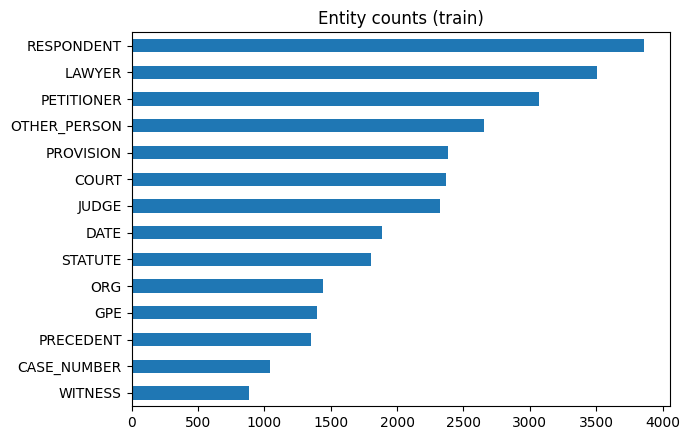

He was also asked whether Agya <span class="hidden_text" id="span_5"> CRA No.326-DB of 1998 6</span> Kaur, mother-in-law of the deceased lived separately from Tarlochan Singh.
[('Agya', 'OTHER_PERSON'), ('Kaur', 'OTHER_PERSON'), ('Tarlochan Singh', 'OTHER_PERSON')]


In [6]:
cnt = Counter(e[2] for d in full_train for e in d["entities"])
pd.Series(cnt).sort_values().plot.barh(figsize=(7, 4.5), title="Entity counts (train)")
plt.tight_layout(); plt.show()
ex = next(d for d in full_train if len(d["entities"]) >= 3)
print(ex["text"][:400]); print([(ex["text"][s:e], l) for s, e, l in ex["entities"]])

## 3. Tokenization: aligning character spans to BIO tags
Character offsets from each tokenizer are mapped onto the gold spans. Whitespace-only tokens and special tokens get label `-100`, which excludes them from the loss. Long documents are split into overlapping windows of `MAX_LEN` tokens.

In [7]:
def _eff_offsets(text, offs, seq_ids):
    """(start,end) per token with leading whitespace stripped; None for special/whitespace tokens."""
    out = []
    for (s, e), sid in zip(offs, seq_ids):
        if sid is None or e <= s:
            out.append(None); continue
        while s < e and text[s].isspace():
            s += 1
        out.append((s, e) if s < e else None)
    return out

def encode_docs(docs, tok):
    enc = tok([d["text"] for d in docs], max_length=MAX_LEN, stride=STRIDE, truncation=True,
              return_overflowing_tokens=True, return_offsets_mapping=True)
    feats = []
    for i, di in enumerate(enc["overflow_to_sample_mapping"]):
        d = docs[di]
        offs = _eff_offsets(d["text"], enc["offset_mapping"][i], enc.sequence_ids(i))
        labels = [-100 if o is None else 0 for o in offs]
        for s, e, lab in d["entities"]:
            first = True
            for t, o in enumerate(offs):
                if o is not None and o[0] < e and o[1] > s:
                    labels[t] = label2id[("B-" if first else "I-") + lab]; first = False
        feats.append({"input_ids": enc["input_ids"][i], "attention_mask": enc["attention_mask"][i],
                      "labels": labels, "doc_idx": di, "offsets": offs})
    return feats

def to_hf(feats):
    return Dataset.from_dict({k: [f[k] for f in feats] for k in ("input_ids", "attention_mask", "labels")})

## 4. Decoding and metrics (entity-level exact match)

In [8]:
def tags_to_spans(tags, offs):
    spans, cur = [], None
    for t, o in zip(tags, offs):
        if o is None:
            continue
        if t == "O":
            if cur: spans.append(tuple(cur)); cur = None
            continue
        p, lab = t.split("-", 1)
        if p == "B" or cur is None or cur[2] != lab:
            if cur: spans.append(tuple(cur))
            cur = [o[0], o[1], lab]
        else:
            cur[1] = o[1]
    if cur: spans.append(tuple(cur))
    return spans

def span_prf(gold_lists, pred_lists):
    tp, fp, fn = Counter(), Counter(), Counter()
    for g, p in zip(gold_lists, pred_lists):
        g, p = set(map(tuple, g)), set(map(tuple, p))
        for x in p & g: tp[x[2]] += 1
        for x in p - g: fp[x[2]] += 1
        for x in g - p: fn[x[2]] += 1
    f = lambda a, b: a / b if b else 0.0
    rows = {}
    for l in sorted(set(tp) | set(fp) | set(fn)):
        P, R = f(tp[l], tp[l] + fp[l]), f(tp[l], tp[l] + fn[l])
        rows[l] = {"precision": P, "recall": R, "f1": f(2 * P * R, P + R), "support": tp[l] + fn[l]}
    T, FP, FN = sum(tp.values()), sum(fp.values()), sum(fn.values())
    P, R = f(T, T + FP), f(T, T + FN)
    return {"precision": P, "recall": R, "f1": f(2 * P * R, P + R),
            "macro_f1": float(np.mean([r["f1"] for r in rows.values()])) if rows else 0.0}, pd.DataFrame(rows).T

def compute_metrics(eval_pred):
    """Window-level entity F1 on validation (token-index spans), used for best-epoch selection."""
    preds, labels = eval_pred
    golds, prs = [], []
    for p, l in zip(preds, labels):
        offs = [(i, i + 1) if y != -100 else None for i, y in enumerate(l)]
        golds.append(tags_to_spans([id2label[y] if y != -100 else "O" for y in l], offs))
        prs.append(tags_to_spans([id2label.get(int(x), "O") for x in p], offs))
    m, _ = span_prf(golds, prs)
    return {"precision": m["precision"], "recall": m["recall"], "f1": m["f1"]}

def argmax_logits(logits, labels):
    return logits.argmax(-1)

@torch.no_grad()
def predict_docs(model, tok, docs, batch_size=16):
    """Doc-level prediction: logits of overlapping windows are averaged per token, then decoded to char spans."""
    model.eval()
    feats = encode_docs(docs, tok)
    acc = [defaultdict(lambda: None) for _ in docs]
    dev = next(model.parameters()).device
    for b in range(0, len(feats), batch_size):
        chunk = feats[b:b + batch_size]
        batch = tok.pad([{"input_ids": f["input_ids"], "attention_mask": f["attention_mask"]} for f in chunk],
                        return_tensors="pt").to(dev)
        logits = model(**batch).logits.float().cpu()
        for f, lg in zip(chunk, logits):
            store = acc[f["doc_idx"]]
            for t, o in enumerate(f["offsets"]):
                if o is None: continue
                store[o] = lg[t].clone() if store[o] is None else store[o] + lg[t]
    out = []
    for d, store in zip(docs, acc):
        keys = sorted(store)
        tags = [id2label[int(store[k].argmax())] for k in keys]
        out.append(clean_spans(d["text"], tags_to_spans(tags, keys)))
    return out

def clean_spans(text, spans, trail=" \t\n,;:"):
    """Trim trailing punctuation that a token may have dragged across the entity boundary."""
    out = []
    for s, e, l in spans:
        while e > s and text[e - 1] in trail: e -= 1
        if e > s: out.append((s, e, l))
    return out

def tokenizer_ceiling(tok, docs):
    """F1 achievable with *perfect* tags given this tokenizer's boundaries (alignment upper bound)."""
    feats = encode_docs(docs, tok)
    acc = [dict() for _ in docs]
    for f in feats:
        for o, y in zip(f["offsets"], f["labels"]):
            if o is not None: acc[f["doc_idx"]][o] = id2label[y]
    preds = [clean_spans(d["text"], tags_to_spans([a[k] for k in sorted(a)], sorted(a))) for d, a in zip(docs, acc)]
    return span_prf([d["entities"] for d in docs], preds)[0]["f1"]

## 5. Model factory (4-bit base, LoRA adapters, trainable token-classification head)

In [9]:
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj", "qkv_proj", "gate_proj", "up_proj", "down_proj", "gate_up_proj"]

def load_tokenizer(ckpt):
    tok = AutoTokenizer.from_pretrained(ckpt, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.unk_token or tok.eos_token
    tok.padding_side = "right"
    return tok

def load_base(ckpt, tok):
    compute_dtype = torch.bfloat16 if BF16 else (torch.float16 if HAS_CUDA else torch.float32)
    kw = dict(num_labels=len(BIO), id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)
    if USE_4BIT:
        kw["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=compute_dtype, llm_int8_skip_modules=["score"])
        kw["device_map"] = {"": 0}
    kw["dtype"] = compute_dtype
    if "gemma" in ckpt.lower():
        kw["attn_implementation"] = "eager"
    model = AutoModelForTokenClassification.from_pretrained(ckpt, **kw)
    model.config.pad_token_id = tok.pad_token_id
    return model

def build_model(ckpt):
    tok = load_tokenizer(ckpt)
    model = load_base(ckpt, tok)
    if USE_4BIT:
        model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True,
                                                gradient_checkpointing_kwargs={"use_reentrant": False})
    names = {n.split(".")[-1] for n, _ in model.named_modules()}
    cfg = LoraConfig(task_type=TaskType.TOKEN_CLS, r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
                     target_modules=[t for t in LORA_TARGETS if t in names])
    model = get_peft_model(model, cfg)
    model.print_trainable_parameters()
    return model, tok

def make_args(out, n_train):
    steps = max(1, (n_train // (BATCH * GRAD_ACC)) * EPOCHS)
    kw = dict(output_dir=out, per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH * 2,
              gradient_accumulation_steps=GRAD_ACC, learning_rate=LR, num_train_epochs=EPOCHS,
              warmup_steps=int(0.05 * steps), lr_scheduler_type="cosine", weight_decay=0.01,
              logging_steps=50, eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
              load_best_model_at_end=True, metric_for_best_model="f1", greater_is_better=True,
              bf16=BF16, fp16=FP16, report_to="none", seed=SEED,
              optim="paged_adamw_8bit" if USE_4BIT else "adamw_torch")
    p = inspect.signature(TrainingArguments.__init__).parameters
    if "group_by_length" in p: kw["group_by_length"] = True
    elif "train_sampling_strategy" in p: kw["train_sampling_strategy"] = "group_by_length"
    return TrainingArguments(**kw)

## 6. Train and evaluate each model
Each model is trained, its best epoch (by validation F1) is kept, and it is then scored on the test set. Results go to `runs/<model>/results.json`, and a model that already has results is skipped.

In [10]:
def run_experiment(name, ckpt):
    out = os.path.join(OUT_DIR, name)
    res_path = os.path.join(out, "results.json")
    if os.path.exists(res_path):
        print(f"[{name}] cached results found, skipping"); return json.load(open(res_path))
    print(f"\n================ {name} ({ckpt}) ================")
    if HAS_CUDA: torch.cuda.reset_peak_memory_stats()
    model, tok = build_model(ckpt)
    tr_feats, va_feats = encode_docs(train_docs, tok), encode_docs(val_docs, tok)
    print(f"windows: train={len(tr_feats)} val={len(va_feats)}")
    trainer_kw = dict(model=model, args=make_args(out, len(tr_feats)),
                      train_dataset=to_hf(tr_feats), eval_dataset=to_hf(va_feats),
                      data_collator=DataCollatorForTokenClassification(tok, pad_to_multiple_of=8),
                      compute_metrics=compute_metrics, preprocess_logits_for_metrics=argmax_logits)
    trainer_kw["processing_class" if "processing_class" in inspect.signature(Trainer.__init__).parameters
               else "tokenizer"] = tok
    trainer = Trainer(**trainer_kw)
    t0 = time.time(); trainer.train(); train_time = time.time() - t0

    best_dir = os.path.join(out, "best")
    trainer.save_model(best_dir); tok.save_pretrained(best_dir)

    t0 = time.time(); preds = predict_docs(trainer.model, tok, test_docs); infer_time = time.time() - t0
    overall, per_label = span_prf([d["entities"] for d in test_docs], preds)
    res = {"model": name, "checkpoint": ckpt, **overall, "tokenizer_ceiling_f1": tokenizer_ceiling(tok, test_docs),
           "train_minutes": train_time / 60, "test_docs_per_sec": len(test_docs) / infer_time,
           "trainable_params_M": sum(p.numel() for p in trainer.model.parameters() if p.requires_grad) / 1e6,
           "peak_gpu_GB": torch.cuda.max_memory_allocated() / 1e9 if HAS_CUDA else None,
           "per_label_f1": per_label["f1"].to_dict(), "best_dir": best_dir,
           "val_log": [h for h in trainer.state.log_history if "eval_f1" in h]}
    json.dump(res, open(res_path, "w"), indent=2)
    print(f"[{name}] TEST  P={res['precision']:.4f} R={res['recall']:.4f} F1={res['f1']:.4f} macroF1={res['macro_f1']:.4f}")
    del trainer, model; gc.collect()
    if HAS_CUDA: torch.cuda.empty_cache()
    return res

results = [run_experiment(n, c) for n, c in MODELS.items()]


================ TinyLlama-1.1B (TinyLlama/TinyLlama-1.1B-Chat-v1.0) ================


Loading weights: 100%|██████████| 200/200 [00:02<00:00, 92.11it/s] 
[transformers] LlamaForTokenClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.bias     | MISSING    | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 12,675,101 || all params: 1,047,246,906 || trainable%: 1.2103
windows: train=12973 val=1288


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.320624,0.166875,0.518441,0.703293,0.596883
2,0.220106,0.147715,0.592612,0.726409,0.652724


[TinyLlama-1.1B] TEST  P=0.5752 R=0.7305 F1=0.6436 macroF1=0.6285

================ Qwen2.5-1.5B (Qwen/Qwen2.5-1.5B) ================


...

[Qwen2.5-1.5B] TEST  P=0.5761 R=0.6061 F1=0.5908 macroF1=0.5896

================ Phi-3-mini-3.8B (microsoft/Phi-3-mini-4k-instruct) ================


c:\Users\TANYA\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\TANYA\.cache\huggingface\hub\models--microsoft--Phi-3-mini-4k-instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 194/194 [00:10<00:00, 17.71it/s]
[transformers]

trainable params: 25,254,941 || all params: 3,747,923,002 || trainable%: 0.6738
windows: train=12961 val=1288


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.356505,0.171357,0.520568,0.672572,0.586888
2,0.208419,0.146496,0.575195,0.724771,0.641377


[Phi-3-mini-3.8B] TEST  P=0.5550 R=0.7204 F1=0.6270 macroF1=0.6143


## 7. Word-boundary snapping, relaxed metrics, bidirectional attention and final model

Sections 1–6 train and score the three models. This section builds on their saved adapters:

1. **Word-boundary snapping**: a post-processing step that fixes spans which start or end in the middle of a word. No retraining is needed.
2. **Relaxed metrics**: overlap F1 and boundary-only F1, reported next to the exact-match scores.
3. **Bidirectional attention** for the decoder, with tests.
4. **TinyLlama ablation**: causal vs bidirectional, trained with the same configuration as the original run.
5. **Re-selection of the final model** over model × attention × snapping.

Only the setup cells and the definition cells of sections 2–5 need to be executed first. The training cell (section 6) does not, because its results are read back from `runs/<model>/results.json`. Nothing in `runs/` or `final_legal_ner_model/` is written to; all new output goes to `runs_v2/` and `final_legal_ner_model_v2/`.

In [15]:
import dataclasses, shutil, transformers, transformers.masking_utils as masking_utils
from transformers import TrainerCallback
from transformers.trainer_utils import get_last_checkpoint, IntervalStrategy, SaveStrategy

SNAP_TO_WORDS     = True    # snap predicted spans to whole words (section 7.1)
USE_BIDIRECTIONAL = False   # default attention mode used by build_model_v2 / load_base_v2 (section 7.3)
V2_DIR            = "runs_v2"
os.makedirs(V2_DIR, exist_ok=True)

# results of the original three runs, read back from disk (the training cell is not re-executed)
results = [json.load(open(os.path.join(OUT_DIR, n, "results.json"))) for n in MODELS]
print("transformers", transformers.__version__, "| original runs:", [(r["model"], round(r["f1"], 4)) for r in results])

transformers 5.18.0 | original runs: [('TinyLlama-1.1B', 0.6436), ('Qwen2.5-1.5B', 0.5908), ('Phi-3-mini-3.8B', 0.627)]


### 7.1 Word-boundary snapping

Tokens from these tokenizers do not always line up with words: `" Sessions"` can split as `" S" + "essions"`. When the model tags only part of a word, the span is cut in the middle of it. `snap_spans` handles this in three steps:

1. **Extend cut words.** If a span edge falls inside a word, it moves outwards until the word is whole.
2. **Merge same-label spans** that overlap or touch.
3. **Resolve label conflicts.** Where spans with different labels still overlap, the longer span is kept.

The step is controlled by `SNAP_TO_WORDS`, which is the default for the `snap` argument of `predict_docs`. `clean_spans`' trimming of trailing `,;:` still applies.

**What counts as a word.** The first version defined a word as a run of non-whitespace characters (`word="nonspace"`). That rule hurts on this corpus because court text glues honorifics and punctuation onto names, and the gold spans exclude them:
- `Sri.[S.Sidhardhan]`, `Mr.[Gautam Tiwari]`, `[Joshi],Assistant` (brackets mark the gold span)
- Snapping these whole changes **1,120 of the 13,365 test gold spans**, and the snapped tokenizer ceiling drops from 0.980 to about 0.91 (diagnostic table below).

The default rule (`word="class"`) only joins a letter to a letter or a digit to a digit. It repairs `S|essions`, `Bhask|aran` and `Kumar K|ait`, but it does not cross `.`, `,` or `/`. It also leaves letter–digit joins alone, such as the footnote markers in `[Mehta v. Union of India]35`.

In [16]:
SNAP_RULES = {   # may a span edge sit between characters a|b? if the rule joins them, the edge is moved outwards
    "class":    lambda a, b: (a.isalpha() and b.isalpha()) or (a.isdigit() and b.isdigit()),
    "alnum":    lambda a, b: a.isalnum() and b.isalnum(),
    "nonspace": lambda a, b: not a.isspace() and not b.isspace(),
}

def snap_spans(text, spans, word="class"):
    joined, n, out = SNAP_RULES[word], len(text), []
    for s0, e0, l in spans:
        s, e = s0, e0
        while s > 0 and joined(text[s - 1], text[s]): s -= 1           # extend to word boundaries
        while e < n and joined(text[e - 1], text[e]): e += 1
        if word == "nonspace":                                          # ...without absorbing edge punctuation
            while s < s0 and not text[s].isalnum(): s += 1
            while e > e0 and not text[e - 1].isalnum(): e -= 1
        out.append((s, e, l))
    out = clean_spans(text, out)
    merged = []                                                     # merge overlapping/touching same-label spans
    for l in sorted({x[2] for x in out}):
        cur = None
        for s, e, _ in sorted(x for x in out if x[2] == l):
            if cur and s <= cur[1]:
                cur[1] = max(cur[1], e)
            else:
                if cur: merged.append(tuple(cur))
                cur = [s, e, l]
        if cur: merged.append(tuple(cur))
    kept = []                                                       # different labels overlapping -> longer wins
    for s, e, l in sorted(merged, key=lambda x: (-(x[1] - x[0]), x[0])):
        if all(e <= ks or s >= ke for ks, ke, _ in kept):
            kept.append((s, e, l))
    return sorted(kept)

if "_predict_docs_raw" not in globals():
    _predict_docs_raw = predict_docs          # section-4 version (logit averaging + clean_spans)

def predict_docs(model, tok, docs, batch_size=16, snap=None):
    preds = _predict_docs_raw(model, tok, docs, batch_size)
    if SNAP_TO_WORDS if snap is None else snap:
        preds = [snap_spans(d["text"], p) for d, p in zip(docs, preds)]
    return preds

def tokenizer_ceilings(tok, docs, word="class"):
    # (plain, snapped) F1 with perfect tags given this tokenizer's boundaries
    feats = encode_docs(docs, tok)
    acc = [dict() for _ in docs]
    for f in feats:
        for o, y in zip(f["offsets"], f["labels"]):
            if o is not None: acc[f["doc_idx"]][o] = id2label[y]
    preds = [clean_spans(d["text"], tags_to_spans([a[k] for k in sorted(a)], sorted(a))) for d, a in zip(docs, acc)]
    gold = [d["entities"] for d in docs]
    return (span_prf(gold, preds)[0]["f1"],
            span_prf(gold, [snap_spans(d["text"], p, word) for d, p in zip(docs, preds)])[0]["f1"])

# unit tests on the failure cases seen in the section-9 demo outputs
t1 = "the order dated 12th March 2018 passed by the Sessions Judge, Pune."
s = t1.index("essions")
assert [t1[a:b] for a, b, _ in snap_spans(t1, [(s, s + len("essions Judge, Pune"), "COURT")])] == ["Sessions Judge, Pune"]
t2 = "the judgment of this Court in K. Bhaskaran v. Sankaran Vaidhyan Balan, (1999) 7 SCC 510."
k = t2.index("K."); b = t2.index("Bhask"); a = b + 5; e = t2.index("Balan") + 5; p = t2.index("(1999)")
got = snap_spans(t2, [(k, k + 2, "PRECEDENT"), (b, b + 5, "OTHER_PERSON"), (a, e, "PRECEDENT"), (p + 1, p + 16, "PRECEDENT")])
assert [(t2[x:y], l) for x, y, l in got] == [("K.", "PRECEDENT"), ("Bhaskaran v. Sankaran Vaidhyan Balan", "PRECEDENT"),
                                            ("1999) 7 SCC 510", "PRECEDENT")], got
t3 = "Honourable Sri Justice Suresh Kumar Kait And"
s = t3.index("Suresh")
assert [t3[x:y] for x, y, _ in snap_spans(t3, [(s, s + len("Suresh Kumar K"), "JUDGE")])] == ["Suresh Kumar Kait"]
t4 = "By Adv. Sri.S.Sidhardhan and Mr.Gautam Tiwari i/b. Mr.Chandrakirti Zende, Advocate"
g4 = [(t4.index(w), t4.index(w) + len(w), "LAWYER") for w in ("S.Sidhardhan", "Gautam Tiwari", "Chandrakirti Zende")]
assert snap_spans(t4, g4) == g4                                                             # honorifics stay outside
c = t4.index("Chandrakirti")                                                                # "Cha" + "ndrakirti Zende" -> one span
assert [t4[x:y] for x, y, _ in snap_spans(t4, [(c, c + 3, "LAWYER"), (c + 3, c + 18, "LAWYER")])] == ["Chandrakirti Zende"]
assert [(t4[x:y], l) for x, y, l in snap_spans(t4, [(c, c + 6, "JUDGE"), (c + 6, c + 18, "LAWYER")])] == [("Chandrakirti Zende", "LAWYER")]
assert snap_spans(t4, [g4[0], g4[0]]) == [g4[0]]                                            # duplicates merge
print("snap_spans tests passed")

snap_spans tests passed


### 7.2 Relaxed metrics

These sit next to the exact-match `span_prf`:
- **Overlap F1.** A prediction counts as a TP if it overlaps a gold span with the same label. Matching is greedy and each gold span can be matched at most once.
- **Boundary F1.** The character span must match exactly, but the label is ignored.

Each of the three original adapters is reloaded from `runs/<model>/best` and `test_docs` is predicted once. The raw predictions are then scored twice, with snapping off and with snapping on. The snapped tokenizer ceiling is reported as well, to check that snapping never lowers the upper bound. The raw (unsnapped) predictions are cached in `runs_v2/preds_<model>.json`, so scores can be recomputed without another forward pass.

In [17]:
def overlap_prf(gold_lists, pred_lists):
    tp = n_pred = n_gold = 0
    for g, p in zip(gold_lists, pred_lists):
        used = set(); n_pred += len(p); n_gold += len(g)
        for ps, pe, pl in p:
            for j, (gs, ge, gl) in enumerate(g):
                if j not in used and gl == pl and ps < ge and pe > gs:
                    used.add(j); tp += 1; break
    P, R = (tp / n_pred if n_pred else 0.0), (tp / n_gold if n_gold else 0.0)
    return {"precision": P, "recall": R, "f1": 2 * P * R / (P + R) if P + R else 0.0}

def boundary_prf(gold_lists, pred_lists):
    strip = lambda L: [[(s, e, "ENT") for s, e, _ in x] for x in L]
    return span_prf(strip(gold_lists), strip(pred_lists))[0]

def score_preds(docs, preds):
    gold = [d["entities"] for d in docs]
    exact, per_label = span_prf(gold, preds)
    return {**exact, "overlap_f1": overlap_prf(gold, preds)["f1"], "boundary_f1": boundary_prf(gold, preds)["f1"],
            "per_label_f1": per_label["f1"].to_dict()}

# sanity checks
_g = [[(0, 5, "A"), (10, 15, "B")]]
assert overlap_prf(_g, [[(1, 4, "A"), (2, 3, "A"), (10, 15, "A")]]) == {"precision": 1/3, "recall": 1/2, "f1": 0.4}
assert boundary_prf(_g, [[(0, 5, "B"), (10, 14, "B")]])["f1"] == 0.5

def free():
    gc.collect()
    if HAS_CUDA: torch.cuda.empty_cache()

def eval_original(r):
    # raw (unsnapped) test predictions are cached, so scoring/snapping changes never need another forward pass
    path = os.path.join(V2_DIR, f"preds_{r['model']}.json")
    tok = load_tokenizer(r["best_dir"])
    if not os.path.exists(path):
        model = PeftModel.from_pretrained(load_base(r["checkpoint"], tok), r["best_dir"]).eval()
        t0 = time.time(); raw = predict_docs(model, tok, test_docs, snap=False); dt = time.time() - t0
        json.dump({"test_docs_per_sec": len(test_docs) / dt, "preds": raw}, open(path, "w"))
        del model; free()
    cache = json.load(open(path))
    raw = [[tuple(x) for x in p] for p in cache["preds"]]
    snapped = [snap_spans(d["text"], p) for d, p in zip(test_docs, raw)]
    ceil_plain, ceil_snap = tokenizer_ceilings(tok, test_docs)
    return {"model": r["model"], "checkpoint": r["checkpoint"], "adapter_dir": r["best_dir"], "attention": "causal",
            "train_minutes": r["train_minutes"], "test_docs_per_sec": cache["test_docs_per_sec"], "raw": raw,
            "ceiling_f1": {"off": ceil_plain, "on": ceil_snap},
            "scores": {"off": score_preds(test_docs, raw), "on": score_preds(test_docs, snapped)}}

orig_evals = []
for r in results:
    ev = eval_original(r); orig_evals.append(ev)
    print(f"{r['model']:16s} exact F1 snap-off={ev['scores']['off']['f1']:.4f} (results.json: {r['f1']:.4f})  "
          f"snap-on={ev['scores']['on']['f1']:.4f} | ceiling off={ev['ceiling_f1']['off']:.4f} on={ev['ceiling_f1']['on']:.4f}")

Loading weights: 100%|██████████| 200/200 [00:02<00:00, 72.00it/s]
[transformers] LlamaForTokenClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.bias     | MISSING    | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TinyLlama-1.1B   exact F1 snap-off=0.6428 (results.json: 0.6436)  snap-on=0.7044 | ceiling off=0.9798 on=0.9865


Loading weights: 100%|██████████| 338/338 [00:04<00:00, 81.31it/s] 
[transformers] Qwen2ForTokenClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 
score.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Qwen2.5-1.5B     exact F1 snap-off=0.5894 (results.json: 0.5908)  snap-on=0.6347 | ceiling off=0.8826 on=0.8816


Loading weights: 100%|██████████| 194/194 [00:10<00:00, 18.25it/s]
[transformers] Phi3ForTokenClassification LOAD REPORT from: microsoft/Phi-3-mini-4k-instruct
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.bias     | MISSING    | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Phi-3-mini-3.8B  exact F1 snap-off=0.6272 (results.json: 0.6270)  snap-on=0.6949 | ceiling off=0.9806 on=0.9883


In [18]:
def rows_from(ev, name=None):
    return [{"model": name or ev["model"], "attention": ev["attention"], "snap": snap,
             **{k: ev["scores"][snap][k] for k in ("precision", "recall", "f1", "macro_f1", "overlap_f1", "boundary_f1")},
             "tokenizer_ceiling_f1": ev["ceiling_f1"][snap]} for snap in ("off", "on")]

METRIC_COLS = ["precision", "recall", "f1", "macro_f1", "overlap_f1", "boundary_f1"]
tbl_orig = pd.DataFrame([row for ev in orig_evals for row in rows_from(ev)])
display(tbl_orig.style.format(precision=4).hide(axis="index")
        .highlight_max(subset=METRIC_COLS, color="#c6efce"))
for ev in orig_evals:
    c = ev["ceiling_f1"]
    print(f"{ev['model']:16s} ceiling delta from snapping: {c['on'] - c['off']:+.4f}"
          + ("" if c["on"] >= c["off"] else "  <-- snapping lowers the ceiling"))

model,attention,snap,precision,recall,f1,macro_f1,overlap_f1,boundary_f1,tokenizer_ceiling_f1
TinyLlama-1.1B,causal,off,0.5745,0.7294,0.6428,0.6277,0.8287,0.6627,0.9798
TinyLlama-1.1B,causal,on,0.6459,0.7746,0.7044,0.6871,0.8474,0.7355,0.9865
Qwen2.5-1.5B,causal,off,0.5742,0.6054,0.5894,0.5880,0.7839,0.6069,0.8826
Qwen2.5-1.5B,causal,on,0.6320,0.6374,0.6347,0.6322,0.7969,0.6603,0.8816
Phi-3-mini-3.8B,causal,off,0.5557,0.7198,0.6272,0.6142,0.8196,0.6466,0.9806
Phi-3-mini-3.8B,causal,on,0.6325,0.7709,0.6949,0.6802,0.8408,0.7255,0.9883


TinyLlama-1.1B   ceiling delta from snapping: +0.0067
Qwen2.5-1.5B     ceiling delta from snapping: -0.0010  <-- snapping lowers the ceiling
Phi-3-mini-3.8B  ceiling delta from snapping: +0.0077


In [19]:
# why snapping stops at punctuation: the three word definitions on the test set (TinyLlama tokenizer + predictions)
tl = orig_evals[[r["model"] for r in results].index("TinyLlama-1.1B")]
tl_tok = load_tokenizer(tl["adapter_dir"])
gold = [d["entities"] for d in test_docs]
diag = []
for w in ("nonspace", "alnum", "class"):
    changed = sum(len(set(g) - set(snap_spans(d["text"], g, w))) for d, g in zip(test_docs, gold))
    plain, snapped = tokenizer_ceilings(tl_tok, test_docs, w)
    pred = [snap_spans(d["text"], p, w) for d, p in zip(test_docs, tl["raw"])]
    diag.append({"word rule": w, "gold spans changed by snapping": changed, "ceiling (no snap)": plain,
                 "ceiling (snap)": snapped, "TinyLlama exact F1 (snap)": span_prf(gold, pred)[0]["f1"]})
display(pd.DataFrame(diag).set_index("word rule").style.format(precision=4))
print(f"TinyLlama exact F1 without snapping: {tl['scores']['off']['f1']:.4f}  | gold spans: {sum(map(len, gold))}")

,gold spans changed by snapping,ceiling (no snap),ceiling (snap),TinyLlama exact F1 (snap)
word rule,,,,
nonspace,1120,0.9798,0.9068,0.6689
alnum,90,0.9798,0.9827,0.7043
class,39,0.9798,0.9865,0.7044


TinyLlama exact F1 without snapping: 0.6428  | gold spans: 13365


With the `class` rule, snapping raises the tokenizer ceiling for TinyLlama and Phi-3 and adds 4.5–6.8 exact-F1 points for every model.

The one exception is Qwen2.5's ceiling, which drops by 0.001. That is 16 gold spans that perfect tags would get right but snapping changes. They fall into three groups:
- **Annotation quirks**, such as `WP/[ST/2798/2020]`.
- **Words with a missing space** in the source text, such as `deceased[Tekam Anjaiah]`.
- **Qwen tokens that start with punctuation**, such as `,Umesh`. These make two same-label spans touch, so the merge rule joins them.

No span goes the other way, from wrong to right, in that ceiling. Qwen's actual predictions still gain 4.5 points from snapping.

### 7.3 Bidirectional attention

The mechanism below comes from reading the installed `transformers` source (5.x), not from guessing. Two things in that code matter:

- **`masking_utils.create_causal_mask`.** When `config.is_causal` is False, it hands off to `create_bidirectional_mask`. That function keeps only the padding mask: every real token can attend to every other real token, and padded keys stay masked. `LlamaModel.forward` (and the Qwen2 and Phi-3 equivalents) builds its mask through `create_causal_mask`, so this switch reaches every layer.
- **`integrations/sdpa_attention.sdpa_attention_forward`.** When a batch has no padding, the bidirectional mask is skipped (`None`). sdpa then decides causality from `getattr(module, "is_causal", True)`, and `LlamaAttention.__init__` sets that to `True`. So `self_attn.is_causal` has to be switched off as well. Without that, unpadded batches would quietly stay causal.

`set_attention_mode` flips both settings. They are plain attributes on the config and on the attention modules, so they carry through 4-bit loading, `prepare_model_for_kbit_training` (gradient checkpointing only re-runs the layer forward), PEFT wrapping and sdpa. The patch is re-applied whenever a model is loaded for inference (`load_for_inference`).

In [20]:
import inspect as _inspect
assert "is_causal" in _inspect.getsource(masking_utils.create_causal_mask), "mask hook not found in this transformers version"

def set_attention_mode(model, bidirectional):
    cfgs = {id(m.config): m.config for m in model.modules() if hasattr(getattr(m, "config", None), "_attn_implementation")}
    for c in cfgs.values():
        c.is_causal = not bidirectional
    attn = [m for m in model.modules() if type(m).__name__.endswith("Attention") and hasattr(m, "is_causal")]
    for m in attn:
        m.is_causal = not bidirectional
    n_layers = next(iter(cfgs.values())).num_hidden_layers
    assert len(attn) == n_layers, (len(attn), n_layers)
    return model

def attention_mode(model):
    attn = [m.is_causal for m in model.modules() if type(m).__name__.endswith("Attention") and hasattr(m, "is_causal")]
    assert len(set(attn)) == 1
    return "causal" if attn[0] else "bidir"

def load_base_v2(ckpt, tok, bidirectional=None):
    model = load_base(ckpt, tok)
    return set_attention_mode(model, USE_BIDIRECTIONAL if bidirectional is None else bidirectional)

def build_model_v2(ckpt, bidirectional=None):
    # same as build_model (section 5), with the attention patch applied to the base model
    tok = load_tokenizer(ckpt)
    model = load_base_v2(ckpt, tok, bidirectional)
    if USE_4BIT:
        model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True,
                                                gradient_checkpointing_kwargs={"use_reentrant": False})
    names = {n.split(".")[-1] for n, _ in model.named_modules()}
    cfg = LoraConfig(task_type=TaskType.TOKEN_CLS, r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
                     target_modules=[t for t in LORA_TARGETS if t in names])
    model = get_peft_model(model, cfg)
    model.print_trainable_parameters()
    return model, tok

def load_for_inference(ckpt, adapter_dir, bidirectional):
    tok = load_tokenizer(adapter_dir)
    model = PeftModel.from_pretrained(load_base_v2(ckpt, tok, bidirectional), adapter_dir).eval()
    return set_attention_mode(model, bidirectional), tok

In [21]:
# Tests on the exact training stack: 4-bit TinyLlama + prepare_model_for_kbit_training + PEFT + sdpa
tmodel, ttok = build_model_v2(MODELS["TinyLlama-1.1B"], bidirectional=True)
assert tmodel.config._attn_implementation == "sdpa", tmodel.config._attn_implementation
assert tmodel.base_model.model.model.gradient_checkpointing
dev0 = next(tmodel.parameters()).device
ids = ttok(["The appellant Ramesh Kumar challenged the order passed by the Sessions Judge, Pune"],
           return_tensors="pt").input_ids.to(dev0)
L, PAD = ids.shape[1], 9
ids_last = ids.clone(); ids_last[0, -1] = ttok.convert_tokens_to_ids("▁Court")
assert (ids_last != ids).any()
ones = torch.ones_like(ids)
padA = torch.cat([ids, torch.full((1, PAD), ttok.pad_token_id, device=dev0)], 1)
padB = torch.cat([ids, torch.randint(100, 30000, (1, PAD), device=dev0)], 1)
padA_last = torch.cat([ids_last, padA[:, L:]], 1)
pmask = torch.cat([ones, torch.zeros(1, PAD, dtype=ones.dtype, device=dev0)], 1)

def last_hidden(ids, mask):
    return tmodel(input_ids=ids, attention_mask=mask, output_hidden_states=True).hidden_states[-1].float()

def emb_grad(ids, mask, out_pos, in_pos):
    # train mode + gradient checkpointing: |d logits[out_pos] / d embedding[in_pos]|
    emb = tmodel.get_input_embeddings()(ids).detach().requires_grad_(True)
    logits = tmodel(inputs_embeds=emb, attention_mask=mask).logits
    logits[0, out_pos].float().sum().backward()
    return emb.grad[0, in_pos].abs().max().item()

report = []
for bidir in (False, True):
    set_attention_mode(tmodel, bidir)
    tmodel.eval()
    with torch.no_grad():
        h, h_last = last_hidden(ids, ones), last_hidden(ids_last, ones)
        hA, hB, hA_last = last_hidden(padA, pmask), last_hidden(padB, pmask), last_hidden(padA_last, pmask)
    first_tok = (h[0, 1] - h_last[0, 1]).abs().max().item()       # position 0 is <s>; 1 is the first word
    bos = (h[0, 0] - h_last[0, 0]).abs().max().item()
    first_tok_pad = (hA[0, 1] - hA_last[0, 1]).abs().max().item()  # same, through the padded (mask) path
    pad_content = (hA[0, :L] - hB[0, :L]).abs().max().item()       # same mask, different pad tokens
    pad_vs_unpadded = ((hA[0, :L] - h[0, :L]).abs().max() / h[0, :L].abs().max()).item()
    tmodel.train()
    g_last = emb_grad(ids, ones, out_pos=1, in_pos=L - 1)          # last token -> first token, grad-ckpt path
    g_pad = emb_grad(padA, pmask, out_pos=slice(0, L), in_pos=slice(L, L + PAD))
    tmodel.zero_grad(set_to_none=True)
    mode = "bidir" if bidir else "causal"
    report.append({"mode": mode, "first-token Δ (last changed)": first_tok, "<s> Δ": bos, "first-token Δ, padded": first_tok_pad, "pad-content Δ": pad_content,
                   "padded vs unpadded (rel.)": pad_vs_unpadded, "grad first←last": g_last, "grad real←pad": g_pad})
    if bidir:
        assert min(first_tok, bos, first_tok_pad) > 1e-2 and g_last > 0, "bidir: last token must influence the first"
    else:
        assert first_tok == bos == first_tok_pad == g_last == 0, "causal: last token must not influence the first"
    assert pad_content == 0 and g_pad == 0, f"{mode}: padding leaked into real tokens"
    assert pad_vs_unpadded < 0.05, f"{mode}: padded run drifted from unpadded run"   # only sdpa kernel numerics
display(pd.DataFrame(report).set_index("mode").style.format("{:.3g}"))
print("bidirectional attention tests passed")
del tmodel; free()

Loading weights: 100%|██████████| 200/200 [00:03<00:00, 58.25it/s]
[transformers] LlamaForTokenClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.bias     | MISSING    | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 12,675,101 || all params: 1,047,246,906 || trainable%: 1.2103


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


,first-token Δ (last changed),Δ,"first-token Δ, padded",pad-content Δ,padded vs unpadded (rel.),grad first←last,grad real←pad
mode,,,,,,,
causal,0,0,0,0,0.0105,0,0
bidir,2.45,2.07,2.35,0,0.00994,8.64,0


bidirectional attention tests passed


The results table shows what each test measures.
- **Last token changes the first token.** In bidirectional mode, changing the last token moves the first token's hidden state, both in eval mode and through the training graph with gradient checkpointing (gradient > 0). In causal mode both values are exactly 0.
- **Padding cannot leak.** Changing what sits in the padded positions leaves the real tokens bit-identical in both modes, and the gradient from padded inputs to real-token logits is exactly 0.
- **Padded vs unpadded.** The run with padding is compared to the run without it only up to a tolerance. With padding, sdpa uses a materialized-mask kernel instead of the maskless one, so bf16 rounding differs slightly, and this happens in both modes.

### 7.4 Ablation: TinyLlama, causal vs bidirectional

The training configuration is the same as the original run: full data, `EPOCHS=2`, `MAX_LEN=256`, and the same LoRA and optimizer settings via `make_args`. `run_experiment_v2` takes `out_dir` and the attention mode as parameters. It resumes from the last checkpoint in its output directory (`get_last_checkpoint`), and if the run was resumed, the train time it reports covers only the resumed part. Both models are scored with snapping off and with snapping on.

`run_experiment_v2(..., max_steps=20)` runs a quick throughput smoke test without evaluation or checkpoints (measured: 0.92 it/s for the bidirectional variant on an RTX 5060 Laptop, about 24 min per full run).

In [ ]:
class StepTimer(TrainerCallback):
    def __init__(self): self.t = {}
    def on_step_end(self, args, state, control, **kw): self.t[state.global_step] = time.time()

def run_experiment_v2(name, ckpt, out_dir=V2_DIR, bidirectional=False, max_steps=None):
    out = os.path.join(out_dir, name)
    res_path = os.path.join(out, "results.json")
    if max_steps is None and os.path.exists(res_path):
        print(f"[{name}] cached results found, skipping"); return json.load(open(res_path))
    mode = "bidir" if bidirectional else "causal"
    print(f"\n================ {name} ({ckpt}, {mode}{', max_steps=%d' % max_steps if max_steps else ''}) ================")
    if HAS_CUDA: torch.cuda.reset_peak_memory_stats()
    model, tok = build_model_v2(ckpt, bidirectional)
    assert attention_mode(model) == mode
    tr_feats, va_feats = encode_docs(train_docs, tok), encode_docs(val_docs, tok)
    args = make_args(out, len(tr_feats))
    if max_steps:   # smoke test: no eval/checkpointing, just throughput
        args.max_steps, args.logging_steps = max_steps, 5
        args.eval_strategy, args.save_strategy = IntervalStrategy.NO, SaveStrategy.NO
        args.load_best_model_at_end = False
    timer = StepTimer()
    trainer_kw = dict(model=model, args=args, train_dataset=to_hf(tr_feats), eval_dataset=to_hf(va_feats),
                      data_collator=DataCollatorForTokenClassification(tok, pad_to_multiple_of=8),
                      compute_metrics=compute_metrics, preprocess_logits_for_metrics=argmax_logits, callbacks=[timer])
    trainer_kw["processing_class" if "processing_class" in inspect.signature(Trainer.__init__).parameters
               else "tokenizer"] = tok
    trainer = Trainer(**trainer_kw)
    steps_per_epoch = len(trainer.get_train_dataloader()) // GRAD_ACC
    last = get_last_checkpoint(out) if (os.path.isdir(out) and not max_steps) else None
    if last: print("resuming from", last)
    t0 = time.time(); trainer.train(resume_from_checkpoint=last); train_time = time.time() - t0

    if max_steps:
        ts = timer.t; warm = 5
        its = (max_steps - warm) / (ts[max_steps] - ts[warm])
        total = steps_per_epoch * EPOCHS
        res = {"it_per_s": its, "total_steps": total, "projected_train_min": total / its / 60}
        print(f"[{name}] smoke: {its:.2f} it/s (steps {warm}-{max_steps}) -> {total} steps ≈ "
              f"{res['projected_train_min']:.1f} min training (+ 2 val passes + test prediction)")
        del trainer, model; free(); return res

    best_dir = os.path.join(out, "best")
    trainer.save_model(best_dir); tok.save_pretrained(best_dir)
    assert attention_mode(trainer.model) == mode
    t0 = time.time(); raw = predict_docs(trainer.model, tok, test_docs, snap=False); infer_time = time.time() - t0
    json.dump({"test_docs_per_sec": len(test_docs) / infer_time, "preds": raw}, open(os.path.join(out, "test_preds.json"), "w"))
    snapped = [snap_spans(d["text"], p) for d, p in zip(test_docs, raw)]
    ceil_plain, ceil_snap = tokenizer_ceilings(tok, test_docs)
    res = {"model": name, "checkpoint": ckpt, "adapter_dir": best_dir, "attention": mode,
           "train_minutes": train_time / 60, "resumed_from": last, "test_docs_per_sec": len(test_docs) / infer_time,
           "peak_gpu_GB": torch.cuda.max_memory_allocated() / 1e9 if HAS_CUDA else None,
           "ceiling_f1": {"off": ceil_plain, "on": ceil_snap},
           "scores": {"off": score_preds(test_docs, raw), "on": score_preds(test_docs, snapped)},
           "val_log": [h for h in trainer.state.log_history if "eval_f1" in h]}
    json.dump(res, open(res_path, "w"), indent=2)
    for s in ("off", "on"):
        m = res["scores"][s]
        print(f"[{name}] snap={s}  P={m['precision']:.4f} R={m['recall']:.4f} F1={m['f1']:.4f} macroF1={m['macro_f1']:.4f}")
    del trainer, model; free(); return res

In [15]:
res_causal = run_experiment_v2("TinyLlama-causal", MODELS["TinyLlama-1.1B"], V2_DIR, bidirectional=False)
res_bidir  = run_experiment_v2("TinyLlama-bidir",  MODELS["TinyLlama-1.1B"], V2_DIR, bidirectional=True)


================ TinyLlama-causal (TinyLlama/TinyLlama-1.1B-Chat-v1.0, causal) ================


Loading weights: 100%|██████████| 200/200 [00:02<00:00, 69.70it/s]
[transformers] LlamaForTokenClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.bias     | MISSING    | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 12,675,101 || all params: 1,047,246,906 || trainable%: 1.2103


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.316499,0.171792,0.516174,0.702343,0.595037
2,0.222848,0.145750,0.587102,0.723559,0.648227


[TinyLlama-causal] snap=off  P=0.5764 R=0.7301 F1=0.6442 macroF1=0.6283
[TinyLlama-causal] snap=on  P=0.6479 R=0.7769 F1=0.7065 macroF1=0.6893

================ TinyLlama-bidir (TinyLlama/TinyLlama-1.1B-Chat-v1.0, bidir) ================


Loading weights: 100%|██████████| 200/200 [00:03<00:00, 60.86it/s]
[transformers] LlamaForTokenClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.bias     | MISSING    | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 12,675,101 || all params: 1,047,246,906 || trainable%: 1.2103


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.283862,0.151915,0.604622,0.753958,0.671082
2,0.148439,0.096195,0.730073,0.817923,0.771505


[TinyLlama-bidir] snap=off  P=0.7384 R=0.8192 F1=0.7767 macroF1=0.7671
[TinyLlama-bidir] snap=on  P=0.7726 R=0.8327 F1=0.8015 macroF1=0.7922


In [16]:
v2_evals = [res_causal, res_bidir]
tbl = pd.DataFrame([row for ev in orig_evals + v2_evals for row in rows_from(ev)])
tbl["train_min"] = [ev["train_minutes"] for ev in orig_evals + v2_evals for _ in (0, 1)]
tbl["run"] = [d + ev["model"] for d, evs in (("runs/", orig_evals), ("runs_v2/", v2_evals)) for ev in evs for _ in (0, 1)]
tbl = tbl[["run", "attention", "snap"] + METRIC_COLS + ["tokenizer_ceiling_f1", "train_min"]]
display(tbl.style.format(precision=4).format({"train_min": "{:.1f}"}).hide(axis="index")
        .highlight_max(subset=METRIC_COLS, color="#c6efce"))

support = pd.Series(Counter(e[2] for d in test_docs for e in d["entities"]), name="support")
per_label_v2 = pd.DataFrame({f"{ev['attention']} / snap {s}": ev["scores"][s]["per_label_f1"]
                             for ev in v2_evals for s in ("off", "on")}).join(support).sort_values("support", ascending=False)
display(per_label_v2.style.format(precision=3).format({"support": "{:d}"})
        .highlight_max(axis=1, subset=[c for c in per_label_v2 if c != "support"], color="#c6efce"))

run,attention,snap,precision,recall,f1,macro_f1,overlap_f1,boundary_f1,tokenizer_ceiling_f1,train_min
runs/TinyLlama-1.1B,causal,off,0.574484,0.729443,0.642756,0.627745,0.828746,0.662733,0.979779,25.2
runs/TinyLlama-1.1B,causal,on,0.645870,0.774560,0.704385,0.687144,0.847413,0.735481,0.986520,25.2
runs/Qwen2.5-1.5B,causal,off,0.574196,0.605387,0.589379,0.587997,0.783945,0.606862,0.882588,25.8
runs/Qwen2.5-1.5B,causal,on,0.632020,0.637411,0.634704,0.632199,0.796901,0.660334,0.881617,25.8
runs/Phi-3-mini-3.8B,causal,off,0.555684,0.719790,0.627180,0.614175,0.819637,0.646608,0.980594,61.5
runs/Phi-3-mini-3.8B,causal,on,0.632474,0.770894,0.694858,0.680150,0.840803,0.725476,0.988269,61.5
runs_v2/TinyLlama-causal,causal,off,0.576407,0.730116,0.644220,0.628323,0.829603,0.664686,0.979779,24.1
runs_v2/TinyLlama-causal,causal,on,0.647885,0.776880,0.706543,0.689322,0.848899,0.737845,0.986520,24.1
runs_v2/TinyLlama-bidir,bidir,off,0.738351,0.819229,0.776690,0.767057,0.895297,0.793786,0.979779,24.5
runs_v2/TinyLlama-bidir,bidir,on,0.772579,0.832697,0.801512,0.792178,0.903277,0.823551,0.986520,24.5


,causal / snap off,causal / snap on,bidir / snap off,bidir / snap on,support
LAWYER,0.891782,0.915689,0.882068,0.897019,1798
COURT,0.725393,0.783951,0.819813,0.827586,1221
PROVISION,0.796419,0.806099,0.889429,0.895014,1220
RESPONDENT,0.656693,0.703055,0.599122,0.640133,1113
DATE,0.874731,0.893027,0.913831,0.916926,1112
OTHER_PERSON,0.529812,0.664968,0.820647,0.849911,1109
STATUTE,0.717241,0.745116,0.868474,0.884402,975
ORG,0.286575,0.407785,0.620000,0.672485,914
PETITIONER,0.598985,0.690302,0.675966,0.717044,862
GPE,0.562720,0.679268,0.721871,0.767230,721


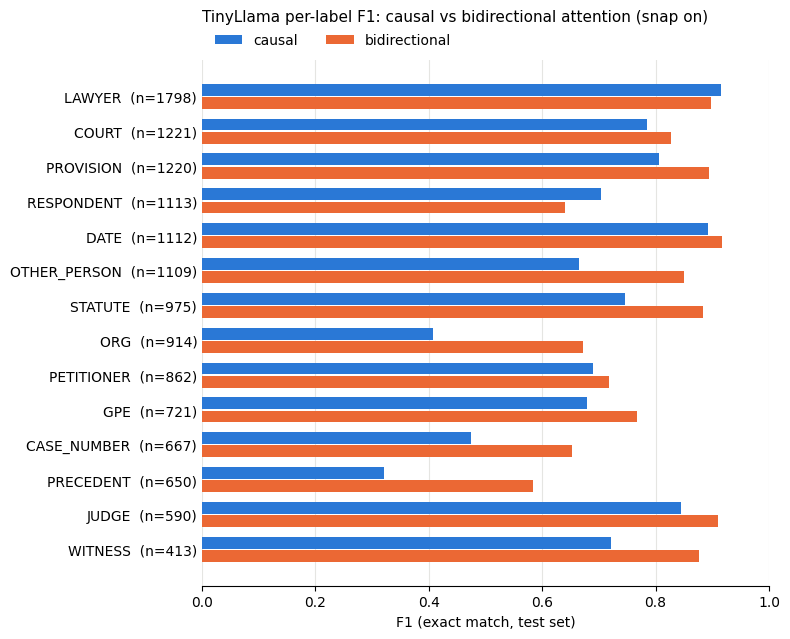

In [15]:
# per-label F1, causal vs bidirectional (TinyLlama, snapping on), labels sorted by test support
snap_key = "on"
pl = pd.DataFrame({m: ev["scores"][snap_key]["per_label_f1"] for m, ev in (("causal", res_causal), ("bidirectional", res_bidir))})
pl = pl.loc[support.sort_values().index]                       # largest support at the top
colors = {"causal": "#2a78d6", "bidirectional": "#eb6834"}
y = np.arange(len(pl)); h = 0.38
fig, ax = plt.subplots(figsize=(8, 6.5))
for i, (m, c) in enumerate(colors.items()):
    ax.barh(y + (h / 2 if i == 0 else -h / 2), pl[m], height=h - 0.04, color=c, label=m)
ax.set_yticks(y, [f"{l}  (n={support[l]})" for l in pl.index])
ax.set_xlim(0, 1); ax.set_xlabel("F1 (exact match, test set)")
ax.set_title(f"TinyLlama per-label F1: causal vs bidirectional attention (snap {snap_key})", loc="left", fontsize=11, pad=28)
ax.grid(axis="x", color="#e5e5e2", lw=0.8); ax.set_axisbelow(True)
for side in ("top", "right", "left"): ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=2, frameon=False)
plt.tight_layout(); plt.show()

### 7.5 Final model selection

Every configuration (model × attention × snapping) is a candidate. The best one is chosen by exact micro F1, with ties broken by macro F1. It replaces the current final model only if its exact F1 is higher than the current model's (0.6436, TinyLlama, causal, no snapping). In that case it is saved to `final_legal_ner_model_v2/`, with a `selection.json` recording the attention mode and the snapping flag. `extract_entities` then loads that model, re-applying the bidirectional patch if one was used, and applies the recorded snapping setting.

In [18]:
cands = [{**row, "checkpoint": ev["checkpoint"], "adapter_dir": ev["adapter_dir"], "run": ev["model"]}
         for ev in orig_evals + v2_evals for row in rows_from(ev)]
best_v2 = max(cands, key=lambda r: (r["f1"], r["macro_f1"]))
cur = json.load(open("final_legal_ner_model/selection.json"))
cur_f1 = next(r["f1"] for r in cur["comparison"] if r["model"] == cur["selected"])
print(f"best configuration: {best_v2['run']} | attention={best_v2['attention']} | snap={best_v2['snap']} | "
      f"F1={best_v2['f1']:.4f} macroF1={best_v2['macro_f1']:.4f}   (current final: {cur['selected']} F1={cur_f1:.4f})")

FINAL_DIR_V2 = "final_legal_ner_model_v2"
if best_v2["f1"] > cur_f1:
    bidir = best_v2["attention"] == "bidir"
    m, t = load_for_inference(best_v2["checkpoint"], best_v2["adapter_dir"], bidir)
    os.makedirs(FINAL_DIR_V2, exist_ok=True)
    m.save_pretrained(FINAL_DIR_V2); t.save_pretrained(FINAL_DIR_V2)
    json.dump({"selected": best_v2["run"], "base_checkpoint": best_v2["checkpoint"], "adapter_dir": best_v2["adapter_dir"],
               "attention": best_v2["attention"], "bidirectional": bidir, "snap_to_words": best_v2["snap"] == "on",
               "metrics": {k: best_v2[k] for k in METRIC_COLS}, "previous_final": {"model": cur["selected"], "f1": cur_f1},
               "labels": BIO, "max_len": MAX_LEN, "stride": STRIDE,
               "comparison": tbl.to_dict(orient="records")}, open(f"{FINAL_DIR_V2}/selection.json", "w"), indent=2)
    del m; free()
    print("saved ->", FINAL_DIR_V2)
else:
    print("no configuration beats the current final model; keeping final_legal_ner_model/")

best configuration: TinyLlama-bidir | attention=bidir | snap=on | F1=0.8015 macroF1=0.7922   (current final: TinyLlama-1.1B F1=0.6436)


Loading weights: 100%|██████████| 200/200 [00:02<00:00, 68.85it/s]
[transformers] LlamaForTokenClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.bias     | MISSING    | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


saved -> final_legal_ner_model_v2


In [19]:
def load_final():
    d = FINAL_DIR_V2 if os.path.exists(f"{FINAL_DIR_V2}/selection.json") else "final_legal_ner_model"
    sel = json.load(open(f"{d}/selection.json"))
    bidir, snap = sel.get("bidirectional", False), sel.get("snap_to_words", False)
    model, tok = load_for_inference(sel["base_checkpoint"], d, bidir)   # bidir patch re-applied on load
    print(f"loaded {d}: {sel['selected']} | attention={attention_mode(model)} | snap_to_words={snap}")
    return model, tok, snap

final_model_v2, final_tok_v2, FINAL_SNAP = load_final()

samples = [   # demo sentences
    "In the High Court of Judicature at Bombay, Criminal Appeal No. 452 of 2019, the appellant Ramesh Kumar "
    "challenged the order dated 12th March 2018 passed by the Sessions Judge, Pune.",
    "The respondent relied on Section 138 of the Negotiable Instruments Act, 1881 and the judgment of this Court "
    "in K. Bhaskaran v. Sankaran Vaidhyan Balan, (1999) 7 SCC 510.",
    "Hon'ble Mr. Justice D.Y. Chandrachud heard Mr. Kapil Sibal, learned senior counsel for the State of Kerala.",
]

def extract_entities(text, model=final_model_v2, tok=final_tok_v2, snap=FINAL_SNAP):
    doc = {"text": text, "entities": []}
    spans = predict_docs(model, tok, [doc], snap=snap)[0]
    return [{"text": text[s:e], "label": l, "start": s, "end": e} for s, e, l in spans]

for s in samples:
    print("\n" + s)
    display(pd.DataFrame(extract_entities(s)))

Loading weights: 100%|██████████| 200/200 [00:03<00:00, 58.52it/s]
[transformers] LlamaForTokenClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.bias     | MISSING    | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


loaded final_legal_ner_model_v2: TinyLlama-bidir | attention=bidir | snap_to_words=True

In the High Court of Judicature at Bombay, Criminal Appeal No. 452 of 2019, the appellant Ramesh Kumar challenged the order dated 12th March 2018 passed by the Sessions Judge, Pune.


,text,label,start,end
0,High Court of Judicature at Bombay,COURT,7,41
1,Criminal Appeal No. 452 of 2019,CASE_NUMBER,43,74
2,Ramesh Kumar,PETITIONER,90,102
3,12th March 2018,DATE,130,145
4,"Sessions Judge, Pune",COURT,160,180



The respondent relied on Section 138 of the Negotiable Instruments Act, 1881 and the judgment of this Court in K. Bhaskaran v. Sankaran Vaidhyan Balan, (1999) 7 SCC 510.


,text,label,start,end
0,Section 138,PROVISION,25,36
1,"Negotiable Instruments Act, 1881",STATUTE,44,76
2,"K. Bhaskaran v. Sankaran Vaidhyan Balan, (1999...",PRECEDENT,111,168



Hon'ble Mr. Justice D.Y. Chandrachud heard Mr. Kapil Sibal, learned senior counsel for the State of Kerala.


,text,label,start,end
0,D.Y. Chandrachud,JUDGE,20,36
1,Kapil Sibal,OTHER_PERSON,47,58
2,of Kerala,GPE,97,106


In [20]:
# gold vs predicted on a random test document (fixed seed)
d = random.Random(1).choice([x for x in test_docs if len(x["entities"]) >= 3])
gold = pd.DataFrame([{"text": d["text"][s:e], "label": l} for s, e, l in d["entities"]]).assign(src="gold")
pred = pd.DataFrame(extract_entities(d["text"]))[["text", "label"]].assign(src="pred")
print(d["text"][:600]); display(pd.concat([gold, pred]).reset_index(drop=True))

Honourable Sri Justice Suresh Kumar Kait And Honourable Sri Justice  N. Balayogi                      

F.C.A.Nos. 99 Of 2006 And batch   

27.02.2018 

Nawab Mir Barkat Ali Khan Waleshan Bahadur,  Prince Mukkaram Jah Bahadur, H.E.H. The Nizam Viii  of Hyderabad rep. by his Sp   
59 years, r/o Hasan Villa H.No.8-2-282/A/4, Road No.3, Banjara Hills, Hyderabad. ... Appellant/


Princess Manolya Jah, Dulkadir Sokak, Adali cikmazi No.9, Arnavutkoy, Istanbul, Turkey & another.... Respondents.Counsel for Petitioner : (1) Sri D.Prakash Reddy & Sri R.Raghunandan Senior Counsel for Sri C.Tulasi Krishna


,text,label,src
0,Suresh Kumar Kait,JUDGE,gold
1,N. Balayogi,JUDGE,gold
2,Nawab Mir Barkat Ali Khan Waleshan Bahadur,PETITIONER,gold
3,Princess Manolya Jah,RESPONDENT,gold
4,D.Prakash Reddy,LAWYER,gold
5,R.Raghunandan,LAWYER,gold
6,C.Tulasi Krishna,LAWYER,gold
7,C.V. Mohan Reddy,LAWYER,gold
8,C.Sumon,LAWYER,gold
9,Ch.Pushyam Kiran,LAWYER,gold


### 7.6 Summary

All scores are on the official 4,501-document test set.

| configuration | exact F1 | macro F1 | overlap F1 | boundary F1 |
|---|---|---|---|---|
| TinyLlama, causal (original final model) | 0.643 | 0.628 | 0.829 | 0.663 |
| TinyLlama, causal + snapping | 0.704 | 0.687 | 0.847 | 0.735 |
| Phi-3-mini, causal + snapping | 0.695 | 0.680 | 0.841 | 0.725 |
| Qwen2.5-1.5B, causal + snapping | 0.635 | 0.632 | 0.797 | 0.660 |
| TinyLlama, bidirectional (retrained) | 0.777 | 0.767 | 0.895 | 0.794 |
| **TinyLlama, bidirectional + snapping (new final model)** | **0.802** | **0.792** | **0.903** | **0.824** |

- **Snapping helps every model without retraining.** It adds 4.5–6.8 exact-F1 points. Most of the gain is in boundary accuracy: boundary F1 rises by 5–7 points, while overlap F1 rises by only 1–2.
- **Bidirectional attention is the largest gain.** Retrained with the same configuration as the causal run (2 epochs, about 24 min each), it adds 13 exact-F1 points without snapping and 9.5 with it. The biggest per-label gains are PRECEDENT (+0.26), ORG (+0.26), OTHER_PERSON (+0.19), CASE_NUMBER (+0.18) and WITNESS (+0.16). These are labels where text to the right of a token decides its type or where the entity ends.
- **RESPONDENT drops** (0.70 → 0.64, snapping on), and LAWYER drops slightly (0.92 → 0.90). In the gold-vs-predicted example, the bidirectional model labels the respondent (`Princess Manolya Jah`) as PETITIONER. PETITIONER and RESPONDENT appear in the same contexts, so the two are easy to confuse.
- **The final model** is `final_legal_ner_model_v2/`. Its `selection.json` records `attention="bidir"` and `snap_to_words=true`. `final_legal_ner_model/` is unchanged.